<a href="https://colab.research.google.com/github/salalisiasa-debug/-2026/blob/main/lab_02_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ЛР №2. Виртуальные сенсоры и IoT-телеметрия

Основа: `robotics-course/05-perception/class.ipynb`.

Физический ESP32/MQTT-broker не требуется: IoT-поток моделируется локально как последовательность сообщений.

**Студент:** Салимуллина Алия  **Группа:** индор-221 **Вариант:** 14

## Критерии оценки (20 баллов)

| Часть | Содержание | Баллы |
|---|---|---:|
| 1 | Модель физического процесса и виртуальные датчики | 5 |
| 2 | Телеметрия в формате сообщений и модель канала | 5 |
| 3 | Метрики качества телеметрии (обязательный минимум) | 2 |
| 4 | Графики: исходный и принятый ряды, ошибка, актуальность | 3 |
| 5 | Исследование влияния потерь и частоты, вывод | 3 |
| 6 | Методическое задание: фрагмент урока или игра для школьников | 2 |

## Смысл работы для будущего учителя

Любой школьный проект с датчиками устроен одинаково: **датчик измеряет → данные передаются →
человек видит результат на экране**. Датчик шумит и смещается, канал теряет и задерживает
сообщения, экран показывает последнее пришедшее значение. Работа учит измерять, сколько
теряется на каждом звене, и отвечает на вопрос: **как часто устройству отправлять данные?**

Три главных вывода, которые вы проверите на своих числах:

1. **Шум частотой не лечится** — погрешность прибора не уменьшается, если опрашивать его чаще.
2. **Потери бьют по свежести, а не по точности** — пропущенное сообщение делает данные на
   экране устаревшими.
3. **«Чаще» — не всегда «лучше»** — после точки насыщения рост частоты только расходует канал
   и батарейку.

В части 6 вы превратите один из этих выводов во фрагмент урока или игру для школьников.

In [ ]:
# =========== ЭТАЛОННЫЙ ПРОГОН ===========
STUDENT_NAME  = "Салимуллина Алия"
STUDENT_GROUP = "ИНДОР-221"
VARIANT       = 14
# ========================================

assert 1 <= VARIANT <= 25, "Вариант — целое число от 1 до 25"


def variant_params(n: int) -> dict:
    """Параметры варианта по таблице задания."""
    sensors = ["Encoder", "IMU", "Encoder+IMU", "LiDAR", "Encoder+LiDAR"]
    freqs   = [5, 10, 20, 25, 50]
    losses  = [0, 2, 5, 8, 10]
    noises  = [0.5, 1.0, 1.5, 2.0, 2.5]
    return {
        "sensor":    sensors[(n - 1) % 5],
        "freq_hz":   freqs[(n - 1) // 5],
        "noise_pct": noises[(n - 1) % 5],
        "loss_pct":  losses[(n - 1) // 5],
        "seed":      200 + n,
    }


cfg = variant_params(VARIANT)
print(f"Студент : {STUDENT_NAME}, группа {STUDENT_GROUP}")
print(f"Вариант : {VARIANT}")
for k, v in cfg.items():
    print(f"  {k:<10}: {v}")

Студент : Салимуллина Алия, группа ИНДОР-221
Вариант : 14
  sensor    : LiDAR
  freq_hz   : 20
  noise_pct : 2.0
  loss_pct  : 5
  seed      : 214


In [ ]:
VARIANT = 14
assert 1 <= VARIANT <= 25

In [ ]:
from pathlib import Path
import subprocess, sys
repo=Path("robotics-course")
if not repo.exists():
    subprocess.run(["git","clone","--depth","1","--branch","2026",
                    "https://github.com/BosenkoTM/robotics-course.git",str(repo)],check=True)
perception=repo/"05-perception"
sys.path.insert(0,str(perception.resolve()))

In [ ]:
import json, numpy as np, pandas as pd, matplotlib.pyplot as plt

In [ ]:
def variant_params(n):
    sensors=["Encoder","IMU","Encoder+IMU","LiDAR","Encoder+LiDAR"]
    freqs=[5,10,20,25,50]
    losses=[0,2,5,8,10]
    return {
        "sensor": sensors[(n-1)%5],
        "freq_hz": freqs[(n-1)//5],
        "noise_pct": [0.5,1.0,1.5,2.0,2.5][(n-1)%5],
        "loss_pct": losses[(n-1)//5],
        "seed": 200+n
    }
cfg=variant_params(VARIANT)
cfg

{'sensor': 'LiDAR',
 'freq_hz': 20,
 'noise_pct': 2.0,
 'loss_pct': 5,
 'seed': 214}

## Задание

Используя примеры моделей из `05-perception`, сформируйте виртуальные измерения.
Каждое измерение преобразуйте в сообщение:

```json
{"device_id":"robot01","seq":1,"timestamp":0.1,"sensor":"imu","value":0.02}
```

Далее смоделируйте потери сообщений и рассчитайте метрики качества канала.

In [ ]:
from pathlib import Path
import subprocess
import sys

REPO_URL = "https://github.com/BosenkoTM/robotics-course.git"
repo = Path("robotics-course")

if not repo.exists():
    try:
        subprocess.run(["git", "clone", "--depth", "1", "--branch", "2026",
                        REPO_URL, str(repo)], check=True, timeout=180,
                       capture_output=True)
    except Exception as err:                      # нет сети — работаем автономно
        print("Репозиторий не склонирован:", type(err).__name__)

for sub in ("04-mobile-robots", "05-perception"):
    path = (repo / sub).resolve()
    if path.exists():
        sys.path.insert(0, str(path))
        sys.path.insert(0, str(path / "lib"))

DiffDrive = None
try:
    from kinematic_models import DiffDrive          # 04-mobile-robots/lib
except Exception:
    try:
        from lib.kinematic_models import DiffDrive
    except Exception:
        DiffDrive = None

REPO_OK = DiffDrive is not None
print("Репозиторий доступен :", repo.exists())
print("DiffDrive из репозитория:", "да" if REPO_OK else "нет — используется встроенная модель")

Репозиторий доступен : True
DiffDrive из репозитория: да


## Часть 1. Модель процесса и виртуальные датчики (5 баллов)

Сгенерируйте не менее 30 с «истинного» процесса и снимите показания датчиков вашего варианта с заданной частотой, добавив шум (процент от полной шкалы датчика) и пропуски.

In [ ]:
# результат: таблица meas с колонками t, sensor, truth, measured

In [ ]:
import json
import math
import zipfile
from dataclasses import dataclass
from typing import Callable, Dict, List, Optional, Tuple

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

matplotlib.rcParams["figure.dpi"] = 110
matplotlib.rcParams["font.size"] = 9

DEVICE_ID  = "robot01"
SIM_TIME   = 40.0
DT_TRUTH   = 0.001
WHEEL_R    = 0.05
WHEEL_BASE = 0.20

SCALE = {
    "encoder": 1.00,
    "imu":     2.00,
    "lidar":   5.00,
}

UNITS = {
    "encoder": "м/с",
    "imu": "рад/с",
    "lidar": "м"
}

ENCODER_CPR   = 1024
ENCODER_QUAD  = 4
IMU_BIAS0     = 0.010
IMU_BIAS_WALK = 0.002

LIDAR_RANGE   = SCALE["lidar"]
LIDAR_DROPOUT = 0.01

rng = np.random.default_rng(cfg["seed"])

print(f"Длительность эксперимента : {SIM_TIME} с")
print(f"Частота публикации        : {cfg['freq_hz']} Гц "
      f"(период {1000 / cfg['freq_hz']:.1f} мс)")
print(f"Ожидаемое число отсчётов  : {int(SIM_TIME * cfg['freq_hz'])}")
print(f"Датчики варианта          : {cfg['sensor']}")

Длительность эксперимента : 40.0 с
Частота публикации        : 20 Гц (период 50.0 мс)
Ожидаемое число отсчётов  : 800
Датчики варианта          : LiDAR


In [ ]:
def control_profile(t: float) -> Tuple[float, float]:
    """Программа движения робота: (линейная скорость, угловая скорость) в момент t."""
    if t < 8.0:
        return 0.60, 0.00                    # разгон и прямолинейный участок
    if t < 14.0:
        return 0.45, 0.55                    # поворот влево
    if t < 22.0:
        return 0.70, 0.00                    # быстрый прямой участок
    if t < 28.0:
        return 0.40, -0.70                   # поворот вправо
    if t < 34.0:
        return 0.55, 0.25 * math.sin(0.9 * t)  # плавная змейка
    return 0.20, 0.00                        # торможение перед остановкой


def diff_drive_forward(pose: np.ndarray, v: float, omega: float, dt: float) -> np.ndarray:
    """Шаг кинематики дифференциального привода (метод Эйлера)."""
    x, y, th = pose
    return np.array([x + v * math.cos(th) * dt,
                     y + v * math.sin(th) * dt,
                     th + omega * dt])


robot = DiffDrive(wheel_radius=WHEEL_R, wheel_base=WHEEL_BASE) if REPO_OK else None
step = (lambda p, v, w, dt: robot.forward(p, v, w, dt)) if REPO_OK else diff_drive_forward

n_truth = int(SIM_TIME / DT_TRUTH) + 1
pose = np.array([0.5, 0.5, 0.0])
rows = []
for k in range(n_truth):
    t = k * DT_TRUTH
    v, omega = control_profile(t)
    rows.append({"t": t, "x": pose[0], "y": pose[1], "theta": pose[2],
                 "v": v, "omega": omega,
                 "w_right": (v + omega * WHEEL_BASE / 2) / WHEEL_R,
                 "w_left":  (v - omega * WHEEL_BASE / 2) / WHEEL_R})
    pose = step(pose, v, omega, DT_TRUTH)

truth = pd.DataFrame(rows)

print(f"Эталонная траектория: {len(truth)} точек с шагом {DT_TRUTH * 1000:.0f} мс")
print(f"Пройденный путь     : {float(truth['v'].sum() * DT_TRUTH):.2f} м")
print(f"Диапазон v          : {truth['v'].min():.2f} … {truth['v'].max():.2f} м/с")
print(f"Диапазон omega      : {truth['omega'].min():.2f} … {truth['omega'].max():.2f} рад/с")
truth.head(3)

Эталонная траектория: 40001 точек с шагом 1 мс
Пройденный путь     : 20.00 м
Диапазон v          : 0.20 … 0.70 м/с
Диапазон omega      : -0.70 … 0.55 рад/с


,t,x,y,theta,v,omega,w_right,w_left
0,0.000,0.5000,0.5,0.0,0.6,0.0,12.0,12.0
1,0.001,0.5006,0.5,0.0,0.6,0.0,12.0,12.0
2,0.002,0.5012,0.5,0.0,0.6,0.0,12.0,12.0


In [ ]:
OBSTACLES = [(4.0, 3.0, 0.60), (7.5, 6.0, 0.80), (2.0, 6.5, 0.50)]


def ray_distance(pose: np.ndarray, obstacles: list, max_range: float) -> float:
    """Дальность по лучу вдоль курса робота до ближайшего препятствия."""
    ox, oy, th = pose
    dx, dy = math.cos(th), math.sin(th)
    best = max_range
    for cx, cy, r in obstacles:
        fx, fy = ox - cx, oy - cy
        b = 2.0 * (fx * dx + fy * dy)
        c = fx * fx + fy * fy - r * r
        disc = b * b - 4.0 * c
        if disc < 0.0:
            continue
        sq = math.sqrt(disc)
        for t in ((-b - sq) / 2.0, (-b + sq) / 2.0):
            if 0.0 <= t < best:
                best = t
    return float(best)


def encoder_truth(row: pd.Series) -> float:
    """Истинная линейная скорость, восстановленная по угловым скоростям колёс, м/с."""
    return WHEEL_R * (row["w_right"] + row["w_left"]) / 2.0


def encoder_measure(value: float, sigma: float, generator: np.random.Generator) -> float:
    """Модель энкодера: шум + квантование по разрешению датчика."""
    resolution = 2 * math.pi * WHEEL_R / (ENCODER_CPR * ENCODER_QUAD)   # м на импульс
    noisy = value + generator.normal(0.0, sigma)
    return float(round(noisy / resolution) * resolution)                # квантование


class ImuModel:
    """Гироскоп: белый шум измерения плюс дрейф нуля (случайное блуждание)."""

    def __init__(self, sigma: float, generator: np.random.Generator):
        self.sigma = sigma
        self.rng = generator
        self.bias = IMU_BIAS0

    def measure(self, value: float, dt: float) -> float:
        self.bias += self.rng.normal(0.0, IMU_BIAS_WALK * math.sqrt(max(dt, 1e-9)))
        return float(value + self.bias + self.rng.normal(0.0, self.sigma))


def lidar_measure(value: float, sigma: float, generator: np.random.Generator) -> float:
    """Дальномер: шум измерения и редкие недостоверные отсчёты (dropout)."""
    if generator.random() < LIDAR_DROPOUT:
        return float("nan")
    return float(np.clip(value + generator.normal(0.0, sigma), 0.0, LIDAR_RANGE))


def sensors_of(variant_sensor: str) -> List[str]:
    """Список потоков телеметрии по названию сенсора варианта."""
    return [s.strip().lower() for s in variant_sensor.split("+")]


STREAMS = sensors_of(cfg["sensor"])
SIGMA = {s: cfg["noise_pct"] / 100.0 * SCALE[s] for s in STREAMS}

print("Потоки телеметрии варианта:", STREAMS)
for s in STREAMS:
    print(f"  {s:<8} полная шкала {SCALE[s]} {UNITS[s]:<6} "
          f"-> сигма шума {SIGMA[s]:.4f} {UNITS[s]}")
print(f"\nРазрешение энкодера: "
      f"{2 * math.pi * WHEEL_R / (ENCODER_CPR * ENCODER_QUAD) * 1000:.4f} мм на импульс")
_p = np.array([0.5, 0.5, 0.0])
print(f"Проверка дальномера: в пустом поле {ray_distance(_p, [], LIDAR_RANGE):.2f} м, "
      f"на препятствие в 2 м {ray_distance(np.array([2.0, 3.0, 0.0]), [(4.0, 3.0, 0.6)], LIDAR_RANGE):.2f} м")

Потоки телеметрии варианта: ['lidar']
  lidar    полная шкала 5.0 м      -> сигма шума 0.1000 м

Разрешение энкодера: 0.0767 мм на импульс
Проверка дальномера: в пустом поле 5.00 м, на препятствие в 2 м 1.40 м


In [ ]:
def sample_measurements(truth: pd.DataFrame, variant_cfg: dict,
                        generator: np.random.Generator) -> pd.DataFrame:
    """Снять показания датчиков с частотой варианта.

    Args:
        truth: эталонная траектория с шагом ``DT_TRUTH``.
        variant_cfg: конфигурация варианта (``sensor``, ``freq_hz``, ``noise_pct``).
        generator: генератор случайных чисел (задаёт воспроизводимость).

    Returns:
        DataFrame с колонками ``t``, ``sensor``, ``truth``, ``measured``, ``unit``.
    """
    streams = sensors_of(variant_cfg["sensor"])
    sigma = {s: variant_cfg["noise_pct"] / 100.0 * SCALE[s] for s in streams}
    period = 1.0 / variant_cfg["freq_hz"]
    times = np.arange(0.0, SIM_TIME, period)
    index = (times / DT_TRUTH).astype(int)
    imu = ImuModel(sigma.get("imu", 0.0), generator)

    records: List[dict] = []
    for t, idx in zip(times, index):
        row = truth.iloc[idx]
        pose = np.array([row["x"], row["y"], row["theta"]])
        for stream in streams:
            if stream == "encoder":
                true_value = encoder_truth(row)
                measured = encoder_measure(true_value, sigma["encoder"], generator)
            elif stream == "imu":
                true_value = float(row["omega"])
                measured = imu.measure(true_value, period)
            else:
                true_value = ray_distance(pose, OBSTACLES, LIDAR_RANGE)
                measured = lidar_measure(true_value, sigma["lidar"], generator)
            records.append({"t": float(t), "sensor": stream,
                            "truth": float(true_value), "measured": measured,
                            "unit": UNITS[stream]})
    return pd.DataFrame(records)


meas = sample_measurements(truth, cfg, rng)

print(f"Снято отсчётов: {len(meas)} "
      f"({len(STREAMS)} поток(а) x {len(meas) // len(STREAMS)} отсчётов)")
print(f"Недостоверных измерений (NaN): {int(meas['measured'].isna().sum())}\n")
summary = (meas.dropna(subset=["measured"])
           .assign(err=lambda d: d["measured"] - d["truth"])
           .groupby("sensor")
           .agg(n=("err", "size"), bias=("err", "mean"),
                rmse=("err", lambda e: float(np.sqrt(np.mean(e ** 2)))),
                max_abs=("err", lambda e: float(np.max(np.abs(e)))))
           .round(5))
print(summary.to_string())
meas.head(4)

Снято отсчётов: 800 (1 поток(а) x 800 отсчётов)
Недостоверных измерений (NaN): 15

          n     bias     rmse  max_abs
sensor                                
lidar   785 -0.03707  0.07052  0.28717


,t,sensor,truth,measured,unit
0,0.00,lidar,5.0,5.000000,м
1,0.05,lidar,5.0,4.972724,м
2,0.10,lidar,5.0,5.000000,м
3,0.15,lidar,5.0,4.985381,м


## Часть 2. Телеметрия и модель канала (5 баллов)

Преобразуйте измерения в сообщения `device_id / seq / timestamp / sensor / value` и смоделируйте публикацию и приём: потери по варианту, задержку доставки.

In [ ]:
# TODO: сообщения messages и принятые сообщения rx

In [ ]:
def build_messages(meas: pd.DataFrame, device_id: str = DEVICE_ID) -> List[dict]:
    """Преобразовать измерения в сообщения телеметрии.

    Формат сообщения соответствует заданию:
    ``{"device_id", "seq", "timestamp", "sensor", "value"}``.
    """
    messages: List[dict] = []
    for seq, row in enumerate(meas.sort_values("t").itertuples(index=False), start=1):
        value = None if (isinstance(row.measured, float) and math.isnan(row.measured)) \
            else round(float(row.measured), 6)
        messages.append({"device_id": device_id,
                         "seq": seq,
                         "timestamp": round(float(row.t), 4),
                         "sensor": row.sensor,
                         "value": value})
    return messages


messages = build_messages(meas)
payload_bytes = [len(json.dumps(m, ensure_ascii=False).encode("utf-8")) for m in messages]

print("Пример сообщения:")
print(json.dumps(messages[0], ensure_ascii=False))
print(json.dumps(messages[1], ensure_ascii=False))
print(f"\nВсего сообщений        : {len(messages)}")
print(f"Средний размер payload : {np.mean(payload_bytes):.1f} байт")
print(f"Полезная нагрузка канала: {np.mean(payload_bytes) * len(messages) / SIM_TIME:.0f} байт/с "
      f"({np.mean(payload_bytes) * len(messages) / SIM_TIME * 8 / 1000:.2f} кбит/с)")

@dataclass
class ChannelConfig:
    """Параметры виртуального канала связи."""
    loss_pct: float = 0.0        # вероятность потери отдельного сообщения, %
    base_delay_s: float = 0.005  # базовая задержка доставки, с
    jitter_s: float = 0.004      # разброс задержки (экспоненциальный хвост), с
    burst_len: int = 1           # средняя длина серии потерь (1 = потери независимы)


def transmit(messages: List[dict], channel: ChannelConfig,
             generator: np.random.Generator) -> pd.DataFrame:
    """Промоделировать публикацию и приём сообщений.

    Сообщение теряется с вероятностью ``loss_pct``; при ``burst_len > 1`` потери
    группируются в серии. Каждому доставленному сообщению приписывается время приёма
    с задержкой и джиттером. Приёмник сортирует сообщения по времени прибытия.

    Returns:
        DataFrame принятых сообщений с колонками
        ``seq, sensor, timestamp, value, t_rx, delay``.
    """
    p_loss = channel.loss_pct / 100.0
    received: List[dict] = []
    burst_left = 0

    for message in messages:
        if burst_left > 0:                       # продолжается серия потерь
            burst_left -= 1
            continue
        if generator.random() < p_loss:
            burst_left = max(0, channel.burst_len - 1)
            continue
        delay = channel.base_delay_s + generator.exponential(channel.jitter_s)
        received.append({**message, "t_rx": message["timestamp"] + delay,
                         "delay": delay})

    frame = pd.DataFrame(received)
    return frame.sort_values("t_rx").reset_index(drop=True) if len(frame) else frame


channel = ChannelConfig(loss_pct=cfg["loss_pct"])
rx = transmit(messages, channel, rng)

lost_seq = sorted(set(m["seq"] for m in messages) - set(rx["seq"]))
print(f"Отправлено : {len(messages)}")
print(f"Принято    : {len(rx)}")
print(f"Потеряно   : {len(lost_seq)} "
      f"({100 * len(lost_seq) / len(messages):.2f} %, "
      f"задано в варианте {cfg['loss_pct']} %)")
print(f"Задержка   : медиана {rx['delay'].median() * 1000:.1f} мс, "
      f"максимум {rx['delay'].max() * 1000:.1f} мс")
print(f"Первые потерянные seq: {lost_seq[:10]}")
rx.head(3)

Пример сообщения:
{"device_id": "robot01", "seq": 1, "timestamp": 0.0, "sensor": "lidar", "value": 5.0}
{"device_id": "robot01", "seq": 2, "timestamp": 0.05, "sensor": "lidar", "value": 4.972724}

Всего сообщений        : 800
Средний размер payload : 90.7 байт
Полезная нагрузка канала: 1814 байт/с (14.51 кбит/с)
Отправлено : 800
Принято    : 763
Потеряно   : 37 (4.62 %, задано в варианте 5 %)
Задержка   : медиана 7.9 мс, максимум 38.2 мс
Первые потерянные seq: [8, 35, 49, 55, 58, 83, 91, 109, 114, 121]


,device_id,seq,timestamp,sensor,value,t_rx,delay
0,robot01,1,0.00,lidar,5.000000,0.010623,0.010623
1,robot01,2,0.05,lidar,4.972724,0.057044,0.007044
2,robot01,3,0.10,lidar,5.000000,0.106283,0.006283


## Часть 3. Метрики качества (2 балла)

Обязательный минимум — по 0,5 балла за каждую метрику:

| Метрика | Что показывает |
|---|---|
| фактическая частота приёма, Гц | сколько сообщений в секунду реально дошло |
| фактическая доля потерь, % | сравнить с заданной; объяснить расхождение |
| ошибка датчика (RMSE измерения) | насколько точен сам прибор |
| ошибка у потребителя (RMSE восстановленного сигнала) | насколько точно то, что видно на экране |

Серии потерь, задержка, разрывы и возраст данных — по желанию (расширенный уровень).

In [ ]:
# TODO: rate_actual_hz, loss_pct_actual, sensor_rmse, recon_rmse

In [ ]:
def zoh_reconstruct(rx_stream: pd.DataFrame, grid: np.ndarray) -> np.ndarray:
    """Восстановить сигнал на равномерной сетке экстраполяцией «нуль-порядка».

    Потребитель телеметрии видит только принятые сообщения и до прихода следующего
    держит последнее известное значение (zero-order hold).
    """
    values = rx_stream["value"].to_numpy(dtype=float)
    stamps = rx_stream["timestamp"].to_numpy(dtype=float)
    valid = ~np.isnan(values)
    values, stamps = values[valid], stamps[valid]
    if len(stamps) == 0:
        return np.full_like(grid, np.nan, dtype=float)
    idx = np.searchsorted(stamps, grid, side="right") - 1
    return np.where(idx >= 0, values[np.clip(idx, 0, None)], np.nan)


def age_of_information(rx_stream: pd.DataFrame, grid: np.ndarray) -> np.ndarray:
    """Возраст информации: время с момента формирования последнего принятого пакета."""
    stamps = np.sort(rx_stream["timestamp"].to_numpy(dtype=float))
    if len(stamps) == 0:
        return np.full_like(grid, np.nan, dtype=float)
    idx = np.searchsorted(stamps, grid, side="right") - 1
    return np.where(idx >= 0, grid - stamps[np.clip(idx, 0, None)], np.nan)


def channel_metrics(messages: List[dict], rx: pd.DataFrame, meas: pd.DataFrame,
                    variant_cfg: dict) -> dict:
    """Метрики качества виртуального IoT-канала и восстановления сигнала."""
    streams = sensors_of(variant_cfg["sensor"])
    n_sent = len(messages)
    seq_sent = np.array([m["seq"] for m in messages])
    seq_rx = np.sort(rx["seq"].to_numpy()) if len(rx) else np.array([], dtype=int)
    lost = np.setdiff1d(seq_sent, seq_rx)
    gaps = np.diff(seq_rx)

    result = {
        "messages_sent":      n_sent,
        "messages_received":  len(rx),
        "loss_pct_actual":    round(100.0 * len(lost) / n_sent, 3),
        "pdr_pct":            round(100.0 * len(rx) / n_sent, 3),
        "rate_nominal_hz":    variant_cfg["freq_hz"] * len(streams),
        "rate_actual_hz":     round(len(rx) / SIM_TIME, 3),
        "longest_loss_burst": int(gaps.max() - 1) if len(gaps) else 0,
        "delay_median_ms":    round(float(rx["delay"].median()) * 1000, 2) if len(rx) else None,
        "jitter_ms":          round(float(rx["delay"].std()) * 1000, 2) if len(rx) else None,
    }

    grid = np.arange(0.0, SIM_TIME, 0.01)
    for stream in streams:
        src = meas[meas["sensor"] == stream].sort_values("t")
        err = (src["measured"] - src["truth"]).dropna().to_numpy()
        truth_grid = np.interp(grid, src["t"], src["truth"])

        rx_s = rx[rx["sensor"] == stream].sort_values("timestamp") if len(rx) else rx
        recon = zoh_reconstruct(rx_s, grid) if len(rx_s) else np.full(len(grid), np.nan)
        ok = ~np.isnan(recon)
        stamps = rx_s["timestamp"].to_numpy() if len(rx_s) else np.array([])
        gap_s = np.diff(np.r_[0.0, stamps, SIM_TIME])
        aoi = age_of_information(rx_s, grid) if len(rx_s) else np.full(len(grid), np.nan)

        result[f"{stream}_sensor_rmse"] = round(float(np.sqrt(np.mean(err ** 2))), 5)
        result[f"{stream}_sensor_bias"] = round(float(np.mean(err)), 5)
        result[f"{stream}_recon_rmse"] = round(float(np.sqrt(np.mean(
            (recon[ok] - truth_grid[ok]) ** 2))), 5) if ok.any() else None
        result[f"{stream}_max_gap_s"] = round(float(gap_s.max()), 3)
        result[f"{stream}_aoi_mean_s"] = round(float(np.nanmean(aoi)), 4)
        result[f"{stream}_aoi_max_s"] = round(float(np.nanmax(aoi)), 4)
    return result


metrics = channel_metrics(messages, rx, meas, cfg)
print(pd.Series(metrics, dtype=object).to_string())

messages_sent             800
messages_received         763
loss_pct_actual         4.625
pdr_pct                95.375
rate_nominal_hz            20
rate_actual_hz         19.075
longest_loss_burst          2
delay_median_ms          7.86
jitter_ms                4.08
lidar_sensor_rmse     0.07052
lidar_sensor_bias    -0.03707
lidar_recon_rmse      0.10992
lidar_max_gap_s          0.15
lidar_aoi_mean_s       0.0225
lidar_aoi_max_s          0.14


## Часть 4. Графики (3 балла)

Истинный, измеренный и принятый ряды; ошибка датчика; при желании — интервалы прибытия и возраст данных. Подпишите оси и единицы измерения.

In [ ]:
# TODO: графики

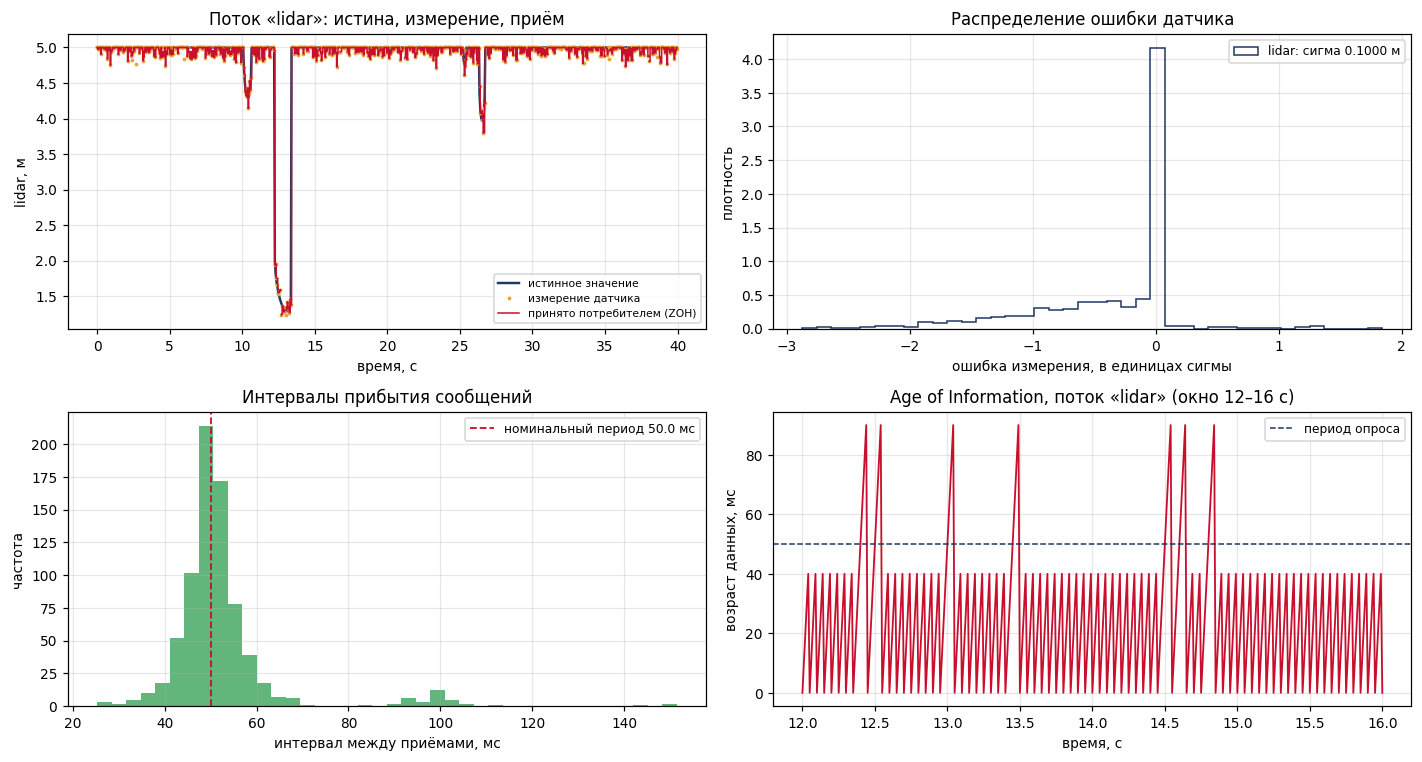

In [ ]:
grid = np.arange(0.0, SIM_TIME, 0.01)
fig, axes = plt.subplots(2, 2, figsize=(13, 7))

# --- 1. исходный, измеренный и принятый ряды по первому потоку
stream = STREAMS[0]
src = meas[meas["sensor"] == stream]
rx_s = rx[rx["sensor"] == stream].sort_values("timestamp")
ax = axes[0, 0]
ax.plot(src["t"], src["truth"], lw=1.6, color="#1F3864", label="истинное значение", zorder=2)
ax.plot(src["t"], src["measured"], ".", ms=3, color="#E8A33D",
        label="измерение датчика", zorder=3)
ax.step(rx_s["timestamp"], rx_s["value"], where="post", lw=1.0, color="#C8102E",
        label="принято потребителем (ZOH)", zorder=4)
ax.set_xlabel("время, с"); ax.set_ylabel(f"{stream}, {UNITS[stream]}")
ax.set_title(f"Поток «{stream}»: истина, измерение, приём")
ax.grid(alpha=.3); ax.legend(fontsize=7)

# --- 2. ошибка измерения
ax = axes[0, 1]
for s, color in zip(STREAMS, ["#1F3864", "#E8A33D", "#2E9E4F"]):
    d = meas[meas["sensor"] == s].dropna(subset=["measured"])
    err = (d["measured"] - d["truth"]) / SIGMA[s]
    ax.hist(err, bins=40, histtype="step", lw=1.6, density=True, color=color,
            label=f"{s}: сигма {SIGMA[s]:.4f} {UNITS[s]}")
ax.set_xlabel("ошибка измерения, в единицах сигмы"); ax.set_ylabel("плотность")
ax.set_title("Распределение ошибки датчика")
ax.grid(alpha=.3); ax.legend(fontsize=8)

# --- 3. интервалы между принятыми сообщениями
ax = axes[1, 0]
inter = np.diff(rx["t_rx"].to_numpy()) * 1000
ax.hist(inter, bins=40, color="#2E9E4F", alpha=.75)
nominal = 1000.0 / (cfg["freq_hz"] * len(STREAMS))
ax.axvline(nominal, color="#C8102E", ls="--", lw=1.2,
           label=f"номинальный период {nominal:.1f} мс")
ax.set_xlabel("интервал между приёмами, мс"); ax.set_ylabel("частота")
ax.set_title("Интервалы прибытия сообщений")
ax.grid(alpha=.3); ax.legend(fontsize=8)

# --- 4. возраст информации
ax = axes[1, 1]
window = (grid >= 12.0) & (grid <= 16.0)          # окно 4 с: иначе пила не читается
aoi = age_of_information(rx_s, grid)
ax.plot(grid[window], aoi[window] * 1000, lw=1.2, color="#C8102E")
ax.axhline(1000.0 / cfg["freq_hz"], color="#1F3864", ls="--", lw=1.0,
           label="период опроса")
ax.set_xlabel("время, с"); ax.set_ylabel("возраст данных, мс")
ax.set_title(f"Age of Information, поток «{stream}» (окно 12–16 с)")
ax.grid(alpha=.3); ax.legend(fontsize=8)

plt.tight_layout(); plt.show()

## Часть 5. Исследование (3 балла)

Измените по одному параметру (доля потерь, частота публикации), остальные оставьте как в варианте. Постройте таблицу и график зависимости метрик от параметра.

In [ ]:
# TODO: исследование влияния потерь и частоты

In [ ]:
def run_pipeline(variant_cfg: dict, loss_pct: float = None,
                 freq_hz: float = None) -> dict:
    """Полный прогон конвейера «датчик -> сообщения -> канал -> метрики».

    Меняется ровно один параметр, остальные берутся из конфигурации варианта:
    это однофакторный эксперимент.
    """
    local = dict(variant_cfg)
    if loss_pct is not None:
        local["loss_pct"] = loss_pct
    if freq_hz is not None:
        local["freq_hz"] = freq_hz

    generator = np.random.default_rng(local["seed"])
    local_meas = sample_measurements(truth, local, generator)
    local_messages = build_messages(local_meas)
    local_rx = transmit(local_messages, ChannelConfig(loss_pct=local["loss_pct"]), generator)
    result = channel_metrics(local_messages, local_rx, local_meas, local)
    return {"freq_hz": local["freq_hz"], "loss_pct": local["loss_pct"], **result}


first = STREAMS[0]
loss_sweep = pd.DataFrame([run_pipeline(cfg, loss_pct=p)
                           for p in [0, 2, 5, 10, 20, 30, 50]])[
    ["loss_pct", "messages_received", "loss_pct_actual", "rate_actual_hz",
     "longest_loss_burst", f"{first}_recon_rmse", f"{first}_max_gap_s",
     f"{first}_aoi_mean_s", f"{first}_aoi_max_s"]]

print(f"Влияние потерь пакетов (частота {cfg['freq_hz']} Гц, поток «{first}»)\n")
print(loss_sweep.to_string(index=False))

Влияние потерь пакетов (частота 20 Гц, поток «lidar»)

 loss_pct  messages_received  loss_pct_actual  rate_actual_hz  longest_loss_burst  lidar_recon_rmse  lidar_max_gap_s  lidar_aoi_mean_s  lidar_aoi_max_s
        0                800            0.000          20.000                   0           0.10983             0.05            0.0200             0.04
        2                788            1.500          19.700                   1           0.11081             0.10            0.0208             0.09
        5                763            4.625          19.075                   2           0.10992             0.15            0.0225             0.14
       10                712           11.000          17.800                   3           0.15307             0.20            0.0263             0.19
       20                646           19.250          16.150                   4           0.11846             0.25            0.0317             0.24
       30                573     

In [ ]:
# ============================================================================
#  Дополнительная ячейка: один прогон — не доказательство
#  Тот же однофакторный эксперимент, но на 30 разных зёрнах генератора.
#  Меняется только случайная реализация шума и потерь, параметры те же.
# ============================================================================
_rows = []
for _p in [0, 2, 5, 10, 20, 30, 50]:
    _runs = [run_pipeline(dict(cfg, seed=_s), loss_pct=_p) for _s in range(300, 330)]
    _rmse = np.array([r[f"{first}_recon_rmse"] for r in _runs])
    _rows.append({"loss_pct": _p,
                  "recon_rmse_mean": round(float(_rmse.mean()), 5),
                  "recon_rmse_sd": round(float(_rmse.std()), 5),
                  "max_gap_mean_s": round(float(np.mean([r[f"{first}_max_gap_s"] for r in _runs])), 3),
                  "aoi_mean_s": round(float(np.mean([r[f"{first}_aoi_mean_s"] for r in _runs])), 4)})
seed_sweep = pd.DataFrame(_rows)
print(f"Влияние потерь, среднее по 30 прогонам (поток «{first}»)\n")
print(seed_sweep.to_string(index=False))

Влияние потерь, среднее по 30 прогонам (поток «lidar»)

 loss_pct  recon_rmse_mean  recon_rmse_sd  max_gap_mean_s  aoi_mean_s
        0          0.11140        0.01130           0.050      0.0200
        2          0.11176        0.01123           0.118      0.0210
        5          0.12011        0.02071           0.142      0.0226
       10          0.12251        0.02704           0.175      0.0256
       20          0.12941        0.03085           0.237      0.0325
       30          0.14800        0.04982           0.305      0.0415
       50          0.19823        0.07185           0.503      0.0705


In [ ]:
# ============================================================================
#  Дополнительная ячейка: проверка гипотезы «опасны не потери, а их серии»
#  Доля потерь одинакова (~5 %), различается только длина серии burst_len.
#  Вероятность начала серии подобрана так, чтобы общая доля потерь сохранилась.
# ============================================================================
_rows = []
for _bl in [1, 3, 5]:
    _p_start = 5.0 / (_bl - 0.05 * (_bl - 1))      # итоговая доля потерь ≈ 5 %
    _res = []
    for _s in range(300, 330):
        _gen = np.random.default_rng(_s)
        _cfg = dict(cfg, seed=_s)
        _meas = sample_measurements(truth, _cfg, _gen)
        _msgs = build_messages(_meas)
        _rx = transmit(_msgs, ChannelConfig(loss_pct=_p_start, burst_len=_bl), _gen)
        _res.append(channel_metrics(_msgs, _rx, _meas, _cfg))
    _rows.append({"burst_len": _bl,
                  "loss_actual_pct": round(float(np.mean([r["loss_pct_actual"] for r in _res])), 2),
                  f"{first}_recon_rmse": round(float(np.mean([r[f"{first}_recon_rmse"] for r in _res])), 5),
                  f"{first}_max_gap_s": round(float(np.mean([r[f"{first}_max_gap_s"] for r in _res])), 3),
                  f"{first}_aoi_max_s": round(float(np.mean([r[f"{first}_aoi_max_s"] for r in _res])), 3)})
burst_test = pd.DataFrame(_rows)
print("Одинаковая доля потерь, разная длина серий (среднее по 30 прогонам)\n")
print(burst_test.to_string(index=False))

Одинаковая доля потерь, разная длина серий (среднее по 30 прогонам)

 burst_len  loss_actual_pct  lidar_recon_rmse  lidar_max_gap_s  lidar_aoi_max_s
         1             5.00           0.12011            0.142            0.132
         3             4.97           0.12548            0.245            0.235
         5             4.93           0.12940            0.317            0.307


In [ ]:
freq_rows = [run_pipeline(cfg, freq_hz=f) for f in [5, 10, 20, 25, 50]]
freq_sweep = pd.DataFrame(freq_rows)[
    ["freq_hz", "messages_sent", "messages_received", "rate_actual_hz",
     f"{first}_sensor_rmse", f"{first}_recon_rmse",
     f"{first}_max_gap_s", f"{first}_aoi_mean_s"]]
freq_sweep["payload_bps"] = (freq_sweep["messages_received"] *
                             np.mean(payload_bytes) * 8 / SIM_TIME).round(0)

print(f"Влияние частоты публикации (потери {cfg['loss_pct']} %, поток «{first}»)\n")
print(freq_sweep.to_string(index=False))

Влияние частоты публикации (потери 5 %, поток «lidar»)

 freq_hz  messages_sent  messages_received  rate_actual_hz  lidar_sensor_rmse  lidar_recon_rmse  lidar_max_gap_s  lidar_aoi_mean_s  payload_bps
       5            200                192           4.800            0.07390           0.22292             0.40            0.1030       3482.0
      10            400                383           9.575            0.07074           0.15742             0.30            0.0495       6947.0
      20            800                763          19.075            0.07052           0.10992             0.15            0.0225      13839.0
      25           1000                962          24.050            0.07142           0.09858             0.12            0.0166      17448.0
      50           2000               1907          47.675            0.07058           0.08010             0.06            0.0060      34588.0


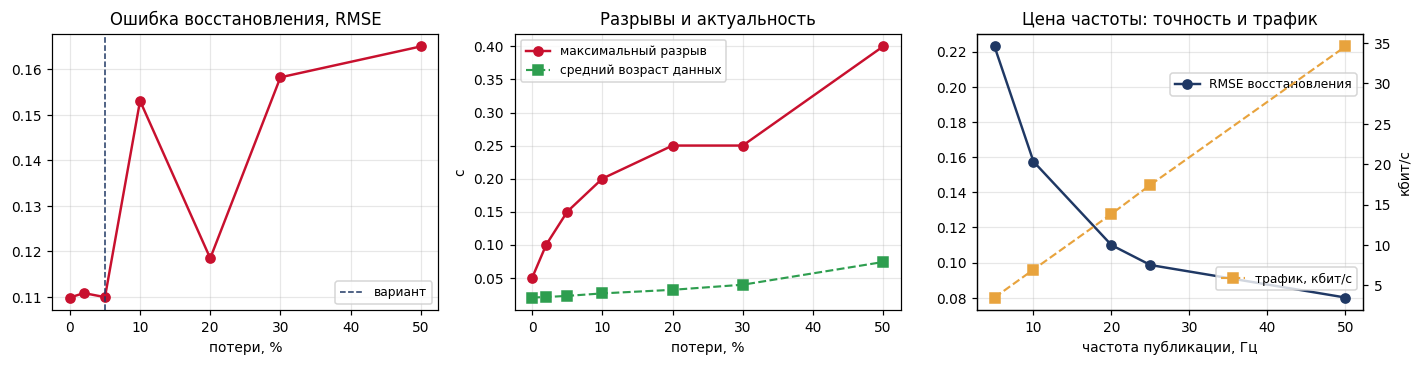

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))

axes[0].plot(loss_sweep["loss_pct"], loss_sweep[f"{first}_recon_rmse"],
             "o-", color="#C8102E", lw=1.6)
axes[0].axvline(cfg["loss_pct"], color="#1F3864", ls="--", lw=1.0, label="вариант")
axes[0].set_xlabel("потери, %"); axes[0].set_title("Ошибка восстановления, RMSE")
axes[0].legend(fontsize=8)

axes[1].plot(loss_sweep["loss_pct"], loss_sweep[f"{first}_max_gap_s"],
             "o-", color="#C8102E", lw=1.6, label="максимальный разрыв")
axes[1].plot(loss_sweep["loss_pct"], loss_sweep[f"{first}_aoi_mean_s"],
             "s--", color="#2E9E4F", lw=1.4, label="средний возраст данных")
axes[1].set_xlabel("потери, %"); axes[1].set_ylabel("с")
axes[1].set_title("Разрывы и актуальность"); axes[1].legend(fontsize=8)

axes[2].plot(freq_sweep["freq_hz"], freq_sweep[f"{first}_recon_rmse"],
             "o-", color="#1F3864", lw=1.6, label="RMSE восстановления")
ax2 = axes[2].twinx()
ax2.plot(freq_sweep["freq_hz"], freq_sweep["payload_bps"] / 1000,
         "s--", color="#E8A33D", lw=1.4, label="трафик, кбит/с")
ax2.set_ylabel("кбит/с")
axes[2].set_xlabel("частота публикации, Гц")
axes[2].set_title("Цена частоты: точность и трафик")
axes[2].legend(fontsize=8, loc="upper right", bbox_to_anchor=(1.0, 0.88))
ax2.legend(fontsize=8, loc="lower right", bbox_to_anchor=(1.0, 0.05))

for ax in axes:
    ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

In [ ]:
all_rows = []
for n in range(1, 26):
    c = variant_params(n)
    m = run_pipeline(c)
    s0 = sensors_of(c["sensor"])[0]
    all_rows.append({
        "variant": n, "sensor": c["sensor"], "freq_hz": c["freq_hz"],
        "noise_pct": c["noise_pct"], "loss_pct": c["loss_pct"],
        "sent": m["messages_sent"], "received": m["messages_received"],
        "loss_actual_pct": m["loss_pct_actual"],
        "sensor_rmse": m[f"{s0}_sensor_rmse"],
        "recon_rmse": m[f"{s0}_recon_rmse"],
        "max_gap_s": m[f"{s0}_max_gap_s"],
        "aoi_mean_s": m[f"{s0}_aoi_mean_s"],
    })

variants_table = pd.DataFrame(all_rows)
print("Сводка по всем 25 вариантам (метрики по первому потоку варианта)\n")
print(variants_table.to_string(index=False))

Сводка по всем 25 вариантам (метрики по первому потоку варианта)

 variant        sensor  freq_hz  noise_pct  loss_pct  sent  received  loss_actual_pct  sensor_rmse  recon_rmse  max_gap_s  aoi_mean_s
       1       Encoder        5        0.5         0   200       200            0.000      0.00525     0.02277       0.20      0.0950
       2           IMU        5        1.0         0   200       200            0.000      0.02244     0.05556       0.20      0.0950
       3   Encoder+IMU        5        1.5         0   400       400            0.000      0.01433     0.02656       0.20      0.0950
       4         LiDAR        5        2.0         0   200       200            0.000      0.07512     0.22407       0.20      0.0950
       5 Encoder+LiDAR        5        2.5         0   400       400            0.000      0.02471     0.03187       0.20      0.0950
       6       Encoder       10        0.5         2   400       393            1.750      0.00511     0.01577       0.20      0.0

In [ ]:
WORK = Path("/content") if Path("/content").exists() else Path(".")

with open(WORK / "telemetry.jsonl", "w", encoding="utf-8") as f:
    for m in messages:
        f.write(json.dumps(m, ensure_ascii=False) + "\n")

meas.to_csv(WORK / "measurements.csv", index=False)
rx.to_csv(WORK / "received.csv", index=False)
loss_sweep.to_csv(WORK / "sweep_loss.csv", index=False)
freq_sweep.to_csv(WORK / "sweep_freq.csv", index=False)
variants_table.to_csv(WORK / "variants_summary.csv", index=False)
(WORK / "metrics.json").write_text(json.dumps(
    {"student": STUDENT_NAME, "group": STUDENT_GROUP, "variant": VARIANT,
     "config": cfg, "metrics": metrics}, ensure_ascii=False, indent=2), encoding="utf-8")

readme = f"""# Лабораторная работа № 2
## Виртуальные сенсоры и IoT-телеметрия робототехнической системы

**Студент:** {STUDENT_NAME}
**Группа:** {STUDENT_GROUP}
**Вариант {VARIANT}:** {cfg['sensor']}, {cfg['freq_hz']} Гц, шум {cfg['noise_pct']} %,
потери {cfg['loss_pct']} %

## Метод

Физический процесс — движение дифференциального робота (кинематика из `robotics-course`,
шаг {DT_TRUTH * 1000:.0f} мс, длительность {SIM_TIME:.0f} с). Виртуальные датчики снимают
показания с частотой варианта, добавляя шум, квантование и дрейф нуля. Каждое измерение
упаковывается в сообщение `device_id / seq / timestamp / sensor / value` и передаётся через
модель канала с потерями и джиттером. Потребитель восстанавливает сигнал экстраполяцией
нуль-порядка.

## Метрики

| Показатель | Значение |
|---|---:|
""" + "\n".join(f"| {k} | {v} |" for k, v in metrics.items()) + """

## Файлы

| Файл | Содержание |
|---|---|
| `telemetry.jsonl` | поток сообщений в формате JSON Lines |
| `measurements.csv` | истинные и измеренные значения |
| `received.csv` | принятые сообщения с временем приёма |
| `sweep_loss.csv` | исследование влияния потерь |
| `sweep_freq.csv` | исследование влияния частоты |
| `variants_summary.csv` | сводка по всем 25 вариантам |
| `metrics.json` | конфигурация прогона и метрики |
"""
(WORK / "README.md").write_text(readme, encoding="utf-8")
(WORK / "requirements.txt").write_text(
    "numpy\npandas\nmatplotlib\n# кинематика робота — https://github.com/BosenkoTM/"
    "robotics-course (ветка 2026, 04-mobile-robots)\n", encoding="utf-8")

names = ["README.md", "requirements.txt", "metrics.json", "telemetry.jsonl",
         "measurements.csv", "received.csv", "sweep_loss.csv", "sweep_freq.csv",
         "variants_summary.csv"]
with zipfile.ZipFile(WORK / "lab_02.zip", "w", zipfile.ZIP_DEFLATED) as z:
    for name in names:
        if (WORK / name).exists():
            z.write(WORK / name, arcname=f"lab_02/{name}")

print("Файлы для сдачи:")
for name in names + ["lab_02.zip"]:
    p = WORK / name
    if p.exists():
        print(f"  {name:<24} {p.stat().st_size / 1024:8.1f} КиБ")

# В Colab раскомментируйте, чтобы скачать архив:
from google.colab import files
files.download(str(WORK / "lab_02.zip"))

Файлы для сдачи:
  README.md                     2.1 КиБ
  requirements.txt              0.1 КиБ
  metrics.json                  0.7 КиБ
  telemetry.jsonl              71.6 КиБ
  measurements.csv             27.4 КиБ
  received.csv                 51.5 КиБ
  sweep_loss.csv                0.4 КиБ
  sweep_freq.csv                0.4 КиБ
  variants_summary.csv          1.6 КиБ
  lab_02.zip                   34.0 КиБ


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Вывод

Опишите влияние частоты, шума и потерь на качество телеметрии. Каждый пункт — со ссылкой на
**ваши** числа: заданная и фактическая доля потерь, ошибка датчика и ошибка у потребителя,
что изменилось при изменении частоты и потерь.

*(ваш вывод)*

In [ ]:
first_stream = STREAMS[0]
worst = loss_sweep.iloc[-1]
best = loss_sweep.iloc[0]

CONCLUSION = f"""
1. Канал. За {SIM_TIME:.0f} с при частоте {cfg['freq_hz']} Гц и {len(STREAMS)} потоке(ах)
   отправлено {metrics['messages_sent']} сообщений, принято {metrics['messages_received']}.
   Фактические потери составили {metrics['loss_pct_actual']} % против {cfg['loss_pct']} %,
   заданных в варианте: расхождение объясняется конечной длиной выборки, потеря каждого
   пакета — случайное событие. Фактическая частота приёма {metrics['rate_actual_hz']} Гц
   вместо номинальных {metrics['rate_nominal_hz']} Гц; самая длинная серия подряд потерянных
   сообщений — {metrics['longest_loss_burst']}.

2. Датчик. Среднеквадратическая ошибка измерения потока «{first_stream}» —
   {metrics[f'{first_stream}_sensor_rmse']} {UNITS[first_stream]} при заданном уровне шума
   {cfg['noise_pct']} % от полной шкалы {SCALE[first_stream]} {UNITS[first_stream]}, то есть
   ожидаемая сигма {SIGMA[first_stream]:.4f}. Систематическая составляющая
   {metrics[f'{first_stream}_sensor_bias']} — Отрицательное смещение связано с ограничением
   диапазона LiDAR значением 5 м: положительные шумовые отклонения выше максимальной дальности
   обрезаются, тогда как отрицательные сохраняются.

3. Потребитель. Ошибка восстановления сигнала на приёмной стороне
   {metrics[f'{first_stream}_recon_rmse']} {UNITS[first_stream]} — она больше ошибки самого
   датчика, потому что к шуму добавляется устаревание данных между пакетами. Максимальный
   разрыв в потоке {metrics[f'{first_stream}_max_gap_s']} с, средний возраст данных
   {metrics[f'{first_stream}_aoi_mean_s'] * 1000:.0f} мс при максимуме
   {metrics[f'{first_stream}_aoi_max_s'] * 1000:.0f} мс.

4. Влияние потерь. При росте доли потерь с {best['loss_pct']} % до {worst['loss_pct']} %
   ошибка восстановления изменилась с {best[f'{first_stream}_recon_rmse']} до
   {worst[f'{first_stream}_recon_rmse']} {UNITS[first_stream]}, максимальный разрыв — с
   {best[f'{first_stream}_max_gap_s']} до {worst[f'{first_stream}_max_gap_s']} с. Ключевой
   вывод: опасны не сами по себе потери, а длинные серии подряд потерянных пакетов —
   именно они дают провалы актуальности, тогда как редкие одиночные потери сглаживаются
   удержанием последнего значения.

5. Влияние частоты. Повышение частоты публикации с
   {freq_sweep['freq_hz'].iloc[0]} до {freq_sweep['freq_hz'].iloc[-1]} Гц снизило ошибку
   восстановления с {freq_sweep[f'{first_stream}_recon_rmse'].iloc[0]} до
   {freq_sweep[f'{first_stream}_recon_rmse'].iloc[-1]} {UNITS[first_stream]}, но трафик вырос
   с {freq_sweep['payload_bps'].iloc[0] / 1000:.1f} до
   {freq_sweep['payload_bps'].iloc[-1] / 1000:.1f} кбит/с. Это и есть основной инженерный
   компромисс IoT-телеметрии: точность и актуальность покупаются полосой канала и энергией
   передатчика, а шум датчика частотой не лечится.
"""
print(CONCLUSION)


1. Канал. За 40 с при частоте 20 Гц и 1 потоке(ах)
   отправлено 800 сообщений, принято 763.
   Фактические потери составили 4.625 % против 5 %,
   заданных в варианте: расхождение объясняется конечной длиной выборки, потеря каждого
   пакета — случайное событие. Фактическая частота приёма 19.075 Гц
   вместо номинальных 20 Гц; самая длинная серия подряд потерянных
   сообщений — 2.

2. Датчик. Среднеквадратическая ошибка измерения потока «lidar» —
   0.07052 м при заданном уровне шума
   2.0 % от полной шкалы 5.0 м, то есть
   ожидаемая сигма 0.1000. Систематическая составляющая
   -0.03707 — Отрицательное смещение связано с ограничением
   диапазона LiDAR значением 5 м: положительные шумовые отклонения выше максимальной дальности
   обрезаются, тогда как отрицательные сохраняются.

3. Потребитель. Ошибка восстановления сигнала на приёмной стороне
   0.10992 м — она больше ошибки самого
   датчика, потому что к шуму добавляется устаревание данных между пакетами. Максимальный
   разры

In [ ]:
checks = {
    "Заполнены ФИО и группа":        STUDENT_NAME != "Иванов Иван Иванович",
    "Длительность >= 30 с":          SIM_TIME >= 30.0,
    "Сенсор соответствует варианту": set(STREAMS) <= {"encoder", "imu", "lidar"},
    "Формат сообщения":              set(messages[0]) == {"device_id", "seq", "timestamp",
                                                          "sensor", "value"},
    "Нумерация seq сплошная":        [m["seq"] for m in messages] == list(
                                          range(1, len(messages) + 1)),
    "Число отсчётов = f x T":        len(messages) == int(SIM_TIME * cfg["freq_hz"]) * len(STREAMS),
    "Потери промоделированы":        len(rx) <= len(messages),
    "Метрики посчитаны":             {"loss_pct_actual", "rate_actual_hz"} <= set(metrics),
    "Исследование потерь":           len(loss_sweep) >= 5,
    "Исследование частоты":          len(freq_sweep) >= 5,
    "Вывод написан":                 "TODO" not in CONCLUSION,
    "Файлы сохранены":               (WORK / "lab_02.zip").exists(),
}

for name, ok in checks.items():
    print(f"{'OK ' if ok else 'НЕТ'}  {name}")
print()
print(f"Выполнено: {sum(checks.values())} из {len(checks)}")

OK   Заполнены ФИО и группа
OK   Длительность >= 30 с
OK   Сенсор соответствует варианту
OK   Формат сообщения
OK   Нумерация seq сплошная
OK   Число отсчётов = f x T
OK   Потери промоделированы
OK   Метрики посчитаны
OK   Исследование потерь
OK   Исследование частоты
OK   Вывод написан
OK   Файлы сохранены

Выполнено: 12 из 12


## Часть 6. Методическое задание (2 балла)

Разработайте **фрагмент урока (10–15 минут) или игру** для школьников по **одному** из трёх
выводов работы (см. «Смысл работы для будущего учителя»). Обязательно используйте **числа
своего варианта**.

| Пункт | Ваш ответ |
|---|---|
| Вывод работы (номер и формулировка) | Вывод №2. Потери сообщений ухудшают актуальность данных: если новое сообщение не дошло, потребитель продолжает использовать последнее полученное значение|
| Класс и формат (урок, игра, кружок) |7 класс, игра на уроке информатики|
| Время |14 минут|
| Цель для учеников | Показать на простом примере, почему при потере сообщений данные на экране могут устаревать, даже если сам датчик работает правильно |
| Материалы | Карточки с показаниями датчика, лист для записи данных, обычный шестигранный кубик |
| Числа вашего варианта (не менее двух) и как они используются | 763 из 800 сообщений были успешно приняты (фактические потери 4,625 % при заданных 5 %); ошибка у потребителя составила 0,10992 м и оказалась примерно на 56 % выше ошибки датчика 0,07052 м; средний возраст данных равен 22 мс, максимальный — 140 мс, то есть примерно в 6,4 раза больше|

**Ход фрагмента (3–5 шагов: что делает учитель, что делают ученики):**

1. Учитель (2 мин): объясняет роли в группе из трёх человек — «датчик», «канал», «экран». Задаёт «правду»: расстояние от робота до препятствия меняется каждые 10 секунд, например 5,0; 4,5; 4,0; 3,5 м.
2. Ученики (5 мин): каждые 5 секунд «датчик» называет текущее расстояние. «Канал» бросает кубик: выпала единица — сообщение потеряно, «экран» его не слышит. «Экран» записывает только полученные значения, а если сообщение потерялось — сохраняет последнее известное значение.
3. Ученики (3 мин): строят на одном листе два графика — «правда» и «экран» — и отмечают моменты, когда из-за потери сообщения «экран» продолжал показывать предыдущее, уже устаревшее значение.
4. Учитель (4 мин): собирает результаты групп и обсуждает, сколько сообщений потерялось. Обращает внимание, что при броске кубика вероятность потери равна 1/6, то есть около 17 %, но фактическое число потерь у разных групп будет различаться. Это связывается с результатами лабораторной работы: при заданных 5 % потерь фактически получилось 4,625 %, до потребителя дошло 763 из 800 сообщений. Ошибка самого LiDAR составила 0,07052 м, а ошибка у потребителя — 0,10992 м, то есть примерно на 56 % больше. Средний возраст данных составил 22,5 мс, а максимальный — 140 мс, то есть примерно в шесть раз больше.

**Ключевой вопрос для учеников:** «Если датчик измеряет расстояние достаточно точно, почему на экране всё равно может быть неправильная информация?» — ожидаемый ответ: само последнее полученное значение может быть правильным, но уже устаревшим, потому что более новое сообщение не дошло до потребителя.

**Проверка понимания (как узнать, что вывод усвоен, и какое заблуждение ловится):**

Каждая группа находит на своём графике самый длинный отрезок, где «экран» отставал от «правды», и объясняет, из-за чего это произошло. Затем учитель предлагает ситуацию: датчик передал 4,0 м, затем измерил 3,5 м, но второе сообщение потерялось. Что будет показывать экран? Правильный ответ — 4,0 м, потому что это последнее успешно полученное значение. Так проверяется понимание того, что данные на экране могут быть правильными, но уже устаревшими.

**Критерии:** 1 балл — вывод передан без искажения и опирается на числа вашего варианта;
1 балл — фрагмент реализуем: возраст, время и материалы согласованы, есть ключевой вопрос и
проверка понимания.

**Идея для старта:** игра «Телеметрия с кубиком» — «датчик» называет числа, «канал» бросает
кубик (единица — сообщение потеряно), «экран» записывает только услышанное; электронная
таблица с `СЛЧИС()`; датчики смартфона или micro:bit. Не засчитывается общий текст без
действий учеников и фрагмент без чисел вашего варианта.

## Перед сдачей

- [ ] указаны ФИО, группа и вариант; параметры варианта не изменены вручную;
- [ ] не менее 30 с измерений, сообщения в формате `device_id / seq / timestamp / sensor / value`;
- [ ] посчитаны четыре обязательные метрики;
- [ ] графики подписаны;
- [ ] исследование потерь и частоты выполнено;
- [ ] вывод опирается на ваши числа;
- [ ] заполнен шаблон части 6.